In [10]:
import h5py
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.interpolate import interp1d
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint_adjoint
import gc
import mne
import time
import sys
import os


from torchdiffeq import odeint

In [11]:
try:
    file_new_raw = '/home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif'
    raw = mne.io.read_raw_fif(file_new_raw, preload=False)
    data_total, times_total = raw[322, 2000:12000]
    data,times= raw[322, 2000:12000]
    ecg_data = -data[0]
    ecg_data_total = -data_total[0]

    # Load the .mat file

    mat = loadmat("/home/shobs/Desktop/DDP/scout_id_309.mat")
    eeg_data_total = mat['Value'][:, 2000:12000]
    eeg_data = mat['Value'][:, 2000:12000]
    sc_data = loadmat('/home/shobs/Desktop/DDP/SC_CC120309-27.mat')
    sc_matrix = sc_data["sc"]

    max_val = np.max(sc_matrix)
    Sw_all = (sc_matrix / max_val) * 0.01 if max_val > 0 else sc_matrix

except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    sys.exit()

non_zero_indices_per_row = [np.nonzero(Sw_all[i, :])[0] for i in range(Sw_all.shape[0])]

Opening raw data file /home/shobs/Desktop/DDP/transdef_mf2pt2_rest_raw.fif...
    Range : 114000 ... 680999 =    114.000 ...   680.999 secs
Ready.


In [12]:
# Move these up, right after the data loading try/except block
def preprocess_signal(signal, fs=1000, lowcut=1.5, highcut=20):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    b, a = butter(4, [lowcut / nyq, highcut / nyq], btype='band')
    filtered = filtfilt(b, a, detrended)
    return (filtered - np.mean(filtered)) / np.std(filtered)

def preprocess_signal_alter(signal, fs=1000, lowcut=1.5, highcut=20, order=4):
    detrended = detrend(signal)
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    filtered = filtfilt(b, a, detrended)
    sig_min, sig_max = filtered.min(), filtered.max()
    denom = sig_max - sig_min
    if denom < 1e-10:
        return np.zeros_like(filtered)
    return 2.0 * (filtered - sig_min) / denom - 1.0

eeg_processed = np.array([preprocess_signal(row, fs=1000, lowcut=1.5, highcut=30) for row in eeg_data])
ecg_processed = preprocess_signal(ecg_data_total, fs=1000, lowcut=0.65, highcut=20)

eeg_processed_alter = np.array([preprocess_signal_alter(row, fs=1000, lowcut=0.5, highcut=30) for row in eeg_data])
ecg_processed_alter = preprocess_signal_alter(ecg_data_total, fs=1000, lowcut=0.65, highcut=20)

In [13]:
# Move this up, right after loading mat
region_names = []
if 'Description' in mat:
    for item in mat['Description']:
        if isinstance(item, np.ndarray) and len(item) > 0 and isinstance(item[0], np.ndarray) and len(item[0]) > 0:
            region_names.append(item[0][0])

if not region_names:
    print("Warning: Could not extract region names, using indices instead.")
    region_names = [f"Region_{i}" for i in range(eeg_data.shape[0])]
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

def lagged_corr_100Hz(
    gamma_env,
    bold_ts,
    fs=100,
    lag_min_s=-10,
    lag_max_s=10,
    detrend=True,
    plot=True,
    label=""
):
    """
    Computes normalized lagged cross-correlation between gamma and BOLD.

    Parameters
    ----------
    gamma_env : array-like
        Gamma envelope (1D)
    bold_ts : array-like
        BOLD time series (1D)
    fs : int
        Sampling frequency (Hz)
    lag_min_s, lag_max_s : float
        Lag window in seconds
    detrend : bool
        Remove linear trend before analysis
    """

    # --- Convert to numpy ---
    g = np.asarray(gamma_env).astype(float)
    b = np.asarray(bold_ts).astype(float)

    # --- Remove NaNs ---
    mask = ~np.isnan(g) & ~np.isnan(b)
    g = g[mask]
    b = b[mask]

    # --- Optional detrending (important for BOLD) ---
    if detrend:
        g = signal.detrend(g)
        b = signal.detrend(b)

    # --- Z-score normalization ---
    g = (g - np.mean(g)) / np.std(g)
    b = (b - np.mean(b)) / np.std(b)

    # --- Cross-correlation ---
    corr = signal.correlate(b, g, mode='full', method='fft')
    lags = signal.correlation_lags(len(b), len(g), mode='full')

    # --- Normalize to correlation coefficient ---
    corr = corr / len(b)

    # --- Convert lag to seconds ---
    lag_seconds = lags / fs

    # --- Restrict lag window ---
    mask_lag = (lag_seconds >= lag_min_s) & (lag_seconds <= lag_max_s)

    lag_seconds = lag_seconds[mask_lag]
    corr = corr[mask_lag]

    # --- Peak detection ---
    idx_peak_pos = np.argmax(corr)
    idx_peak_neg = np.argmin(corr)

    peak_pos_lag = lag_seconds[idx_peak_pos]
    peak_pos_val = corr[idx_peak_pos]

    peak_neg_lag = lag_seconds[idx_peak_neg]
    peak_neg_val = corr[idx_peak_neg]

    # --- Plot ---
    if plot:
        plt.figure(figsize=(6, 4))
        plt.plot(lag_seconds, corr, label="Cross-corr")
        plt.axvline(0, color='k', linestyle='--', label="Zero lag")

        # Mark peaks
        plt.scatter(peak_pos_lag, peak_pos_val, label="Max corr")
        plt.scatter(peak_neg_lag, peak_neg_val, label="Min corr")

        plt.xlabel("Lag (s)")
        plt.ylabel("Correlation (r)")
        plt.title(f"Lagged Correlation (Normalized) {label}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "lags_sec": lag_seconds,
        "corr": corr,
        "peak_positive": (peak_pos_lag, peak_pos_val),
        "peak_negative": (peak_neg_lag, peak_neg_val),
    }

In [14]:
def analyze_channel(eeg_channel, ecg_signal, fs, channel_idx, label_suffix=""):
    """Performs correlation and lagged correlation analysis for a single EEG channel."""

    # Calculate Pearson correlation coefficient
    correlation = np.corrcoef(eeg_channel, ecg_signal)[0, 1]

    # Perform lagged correlation
    lagged_results = lagged_corr_100Hz(eeg_channel, ecg_signal, fs=fs, plot=False)

    peak_pos_lag, peak_pos_val = lagged_results['peak_positive']
    peak_neg_lag, peak_neg_val = lagged_results['peak_negative']

    return {
        'channel_idx': channel_idx,
        'correlation': correlation,
        'peak_positive_lag': peak_pos_lag,
        'peak_positive_val': peak_pos_val,
        'peak_negative_lag': peak_neg_lag,
        'peak_negative_val': peak_neg_val,
        'label_suffix': label_suffix
    }

# Prepare lists to store results
all_results_processed = []
all_results_processed_alter = []

t_duration = 10
fs = 100

# Analyze eeg_processed channels
for i in range(eeg_processed.shape[0]):
    target_signal_eeg_processed = eeg_processed[i, ::10]
    target_signal_ecg_processed = ecg_processed[::10]
    if len(target_signal_eeg_processed) == len(target_signal_ecg_processed):
        results = analyze_channel(
            target_signal_eeg_processed,
            target_signal_ecg_processed,
            fs,
            i,
            label_suffix=" (Original Preprocessing)"
        )
        all_results_processed.append(results)
    else:
        print(f"Skipping eeg_processed channel {i} due to length mismatch.")

# Analyze eeg_processed_alter channels
for i in range(eeg_processed_alter.shape[0]):
    target_signal_eeg_alter = eeg_processed_alter[i, ::10]
    target_signal_ecg_alter = ecg_processed_alter[::10]
    if len(target_signal_eeg_alter) == len(target_signal_ecg_alter):
        results = analyze_channel(
            target_signal_eeg_alter,
            target_signal_ecg_alter,
            fs,
            i,
            label_suffix=" (Alter Preprocessing)"
        )
        all_results_processed_alter.append(results)
    else:
        print(f"Skipping eeg_processed_alter channel {i} due to length mismatch.")

print("Analysis complete for all channels.")

Analysis complete for all channels.


### Results for `eeg_processed` (Original Preprocessing)

In [15]:
for res in all_results_processed:
    print(f"Channel {res['channel_idx']}{res['label_suffix']}:\n" \
          f"  Pearson Correlation: {res['correlation']:.4f}\n" \
          f"  Lagged Correlation Peak (Positive): Lag={res['peak_positive_lag']:.2f}s, Value={res['peak_positive_val']:.4f}\n" \
          f"  Lagged Correlation Peak (Negative): Lag={res['peak_negative_lag']:.2f}s, Value={res['peak_negative_val']:.4f}\n")

Channel 0 (Original Preprocessing):
  Pearson Correlation: 0.0182
  Lagged Correlation Peak (Positive): Lag=0.21s, Value=0.1521
  Lagged Correlation Peak (Negative): Lag=-1.29s, Value=-0.1175

Channel 1 (Original Preprocessing):
  Pearson Correlation: -0.0303
  Lagged Correlation Peak (Positive): Lag=-1.94s, Value=0.1312
  Lagged Correlation Peak (Negative): Lag=0.56s, Value=-0.1176

Channel 2 (Original Preprocessing):
  Pearson Correlation: -0.0303
  Lagged Correlation Peak (Positive): Lag=-2.11s, Value=0.1188
  Lagged Correlation Peak (Negative): Lag=-2.35s, Value=-0.0992

Channel 3 (Original Preprocessing):
  Pearson Correlation: -0.0282
  Lagged Correlation Peak (Positive): Lag=-2.85s, Value=0.1319
  Lagged Correlation Peak (Negative): Lag=1.91s, Value=-0.1285

Channel 4 (Original Preprocessing):
  Pearson Correlation: -0.0148
  Lagged Correlation Peak (Positive): Lag=-0.08s, Value=0.1176
  Lagged Correlation Peak (Negative): Lag=-2.35s, Value=-0.1029

Channel 5 (Original Preproces

### Results for `eeg_processed_alter` (Alter Preprocessing)

In [16]:
for res in all_results_processed_alter:
    print(f"Channel {res['channel_idx']}{res['label_suffix']}:\n" \
          f"  Pearson Correlation: {res['correlation']:.4f}\n" \
          f"  Lagged Correlation Peak (Positive): Lag={res['peak_positive_lag']:.2f}s, Value={res['peak_positive_val']:.4f}\n" \
          f"  Lagged Correlation Peak (Negative): Lag={res['peak_negative_lag']:.2f}s, Value={res['peak_negative_val']:.4f}\n")

Channel 0 (Alter Preprocessing):
  Pearson Correlation: 0.0180
  Lagged Correlation Peak (Positive): Lag=2.61s, Value=0.1327
  Lagged Correlation Peak (Negative): Lag=-1.29s, Value=-0.1123

Channel 1 (Alter Preprocessing):
  Pearson Correlation: -0.0064
  Lagged Correlation Peak (Positive): Lag=0.82s, Value=0.1094
  Lagged Correlation Peak (Negative): Lag=-1.31s, Value=-0.1101

Channel 2 (Alter Preprocessing):
  Pearson Correlation: -0.0309
  Lagged Correlation Peak (Positive): Lag=-2.11s, Value=0.1079
  Lagged Correlation Peak (Negative): Lag=5.07s, Value=-0.0948

Channel 3 (Alter Preprocessing):
  Pearson Correlation: -0.0076
  Lagged Correlation Peak (Positive): Lag=-2.85s, Value=0.1039
  Lagged Correlation Peak (Negative): Lag=1.91s, Value=-0.1159

Channel 4 (Alter Preprocessing):
  Pearson Correlation: -0.0226
  Lagged Correlation Peak (Positive): Lag=-0.22s, Value=0.1001
  Lagged Correlation Peak (Negative): Lag=-2.35s, Value=-0.1004

Channel 5 (Alter Preprocessing):
  Pearson Co

In [17]:
max_positive_correlation = -1
highest_corr_channel_info = None

# Check all_results_processed
for res in all_results_processed:
    if res['correlation'] > max_positive_correlation:
        max_positive_correlation = res['correlation']
        highest_corr_channel_info = {
            'channel_idx': res['channel_idx'],
            'correlation': res['correlation'],
            'label_suffix': res['label_suffix']
        }

# Check all_results_processed_alter
for res in all_results_processed_alter:
    if res['correlation'] > max_positive_correlation:
        max_positive_correlation = res['correlation']
        highest_corr_channel_info = {
            'channel_idx': res['channel_idx'],
            'correlation': res['correlation'],
            'label_suffix': res['label_suffix']
        }

if highest_corr_channel_info:
    channel_idx = highest_corr_channel_info['channel_idx']
    correlation_value = highest_corr_channel_info['correlation']
    label_suffix = highest_corr_channel_info['label_suffix']

    # Get region name
    region_name = region_names[channel_idx] if channel_idx < len(region_names) else f"Unknown Region {channel_idx}"

    print(f"The channel with the highest positive Pearson Correlation is:")
    print(f"  Channel {channel_idx} ({region_name}){label_suffix}: {correlation_value:.4f}")
else:
    print("No positive correlations found.")

The channel with the highest positive Pearson Correlation is:
  Channel 12 (fusiform L) (Alter Preprocessing): 0.1256


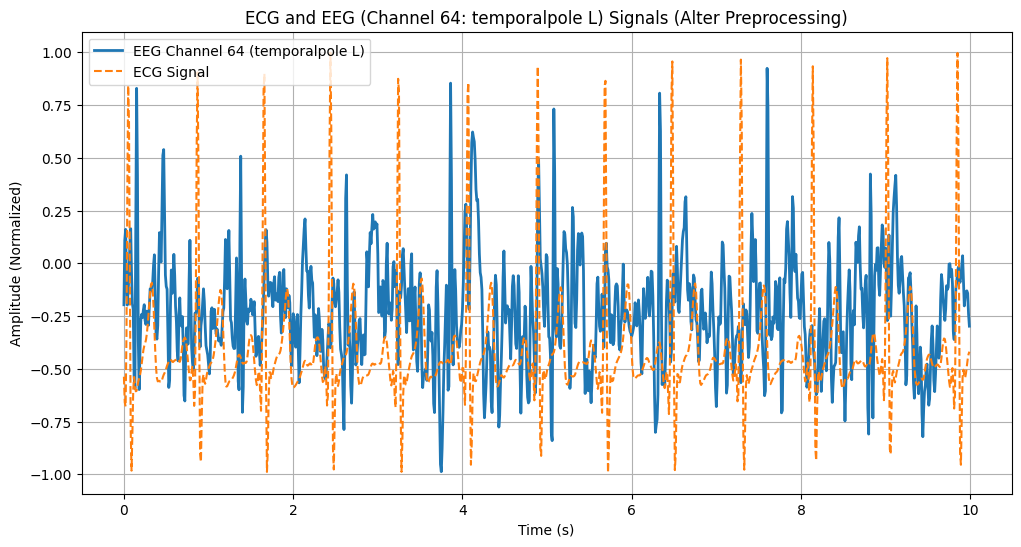

In [18]:
t_duration = 10
fs = 100
t = np.arange(0, t_duration, 1/fs)

channel_to_plot = 64
region_name = region_names[channel_to_plot] if channel_to_plot < len(region_names) else f"Unknown Region {channel_to_plot}"

plt.figure(figsize=(12, 6))

target_signal_eeg_64 = eeg_processed_alter[channel_to_plot, ::10]
target_signal_ecg_64 = ecg_processed_alter[::10]

plt.plot(t, target_signal_eeg_64 , label=f'EEG Channel {channel_to_plot} ({region_name})', linewidth=2)
plt.plot(t, target_signal_ecg_64, label='ECG Signal', linestyle='--')

plt.title(f'ECG and EEG (Channel {channel_to_plot}: {region_name}) Signals (Alter Preprocessing)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

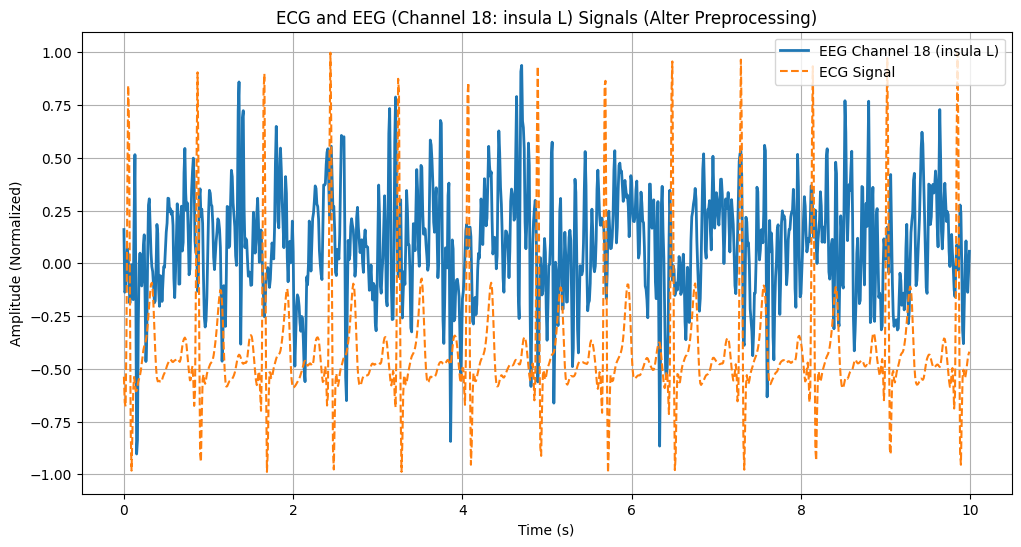

In [19]:
t_duration = 10
fs = 100
t = np.arange(0, t_duration, 1/fs)

channel_to_plot = 18
region_name = region_names[channel_to_plot] if channel_to_plot < len(region_names) else f"Unknown Region {channel_to_plot}"

plt.figure(figsize=(12, 6))

target_signal_eeg_64 = eeg_processed_alter[channel_to_plot, ::10]
target_signal_ecg_64 = ecg_processed_alter[::10]

plt.plot(t, target_signal_eeg_64 , label=f'EEG Channel {channel_to_plot} ({region_name})', linewidth=2)
plt.plot(t, target_signal_ecg_64, label='ECG Signal', linestyle='--')

plt.title(f'ECG and EEG (Channel {channel_to_plot}: {region_name}) Signals (Alter Preprocessing)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (Normalized)')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print("Results for Insula L (Channel 18):")
for res in all_results_processed:
    if res['channel_idx'] == 18:
        print(f"  Original Preprocessing:")
        print(f"    Pearson Correlation: {res['correlation']:.4f}")
        print(f"    Lagged Correlation Peak (Positive): Lag={res['peak_positive_lag']:.2f}s, Value={res['peak_positive_val']:.4f}")
        print(f"    Lagged Correlation Peak (Negative): Lag={res['peak_negative_lag']:.2f}s, Value={res['peak_negative_val']:.4f}")
        break
for res in all_results_processed_alter:
    if res['channel_idx'] == 18:
        print(f"  Alter Preprocessing:")
        print(f"    Pearson Correlation: {res['correlation']:.4f}")
        print(f"    Lagged Correlation Peak (Positive): Lag={res['peak_positive_lag']:.2f}s, Value={res['peak_positive_val']:.4f}")
        print(f"    Lagged Correlation Peak (Negative): Lag={res['peak_negative_lag']:.2f}s, Value={res['peak_negative_val']:.4f}")
        break

print("\nResults for Insula R (Channel 19):")
for res in all_results_processed:
    if res['channel_idx'] == 19:
        print(f"  Original Preprocessing:")
        print(f"    Pearson Correlation: {res['correlation']:.4f}")
        print(f"    Lagged Correlation Peak (Positive): Lag={res['peak_positive_lag']:.2f}s, Value={res['peak_positive_val']:.4f}")
        print(f"    Lagged Correlation Peak (Negative): Lag={res['peak_negative_lag']:.2f}s, Value={res['peak_negative_val']:.4f}")
        break
for res in all_results_processed_alter:
    if res['channel_idx'] == 19:
        print(f"  Alter Preprocessing:")
        print(f"    Pearson Correlation: {res['correlation']:.4f}")
        print(f"    Lagged Correlation Peak (Positive): Lag={res['peak_positive_lag']:.2f}s, Value={res['peak_positive_val']:.4f}")
        print(f"    Lagged Correlation Peak (Negative): Lag={res['peak_negative_lag']:.2f}s, Value={res['peak_negative_val']:.4f}")
        break

Results for Insula L (Channel 18):
  Original Preprocessing:
    Pearson Correlation: 0.0308
    Lagged Correlation Peak (Positive): Lag=0.84s, Value=0.1538
    Lagged Correlation Peak (Negative): Lag=1.58s, Value=-0.1101
  Alter Preprocessing:
    Pearson Correlation: 0.0147
    Lagged Correlation Peak (Positive): Lag=0.85s, Value=0.1329
    Lagged Correlation Peak (Negative): Lag=1.58s, Value=-0.1026

Results for Insula R (Channel 19):
  Original Preprocessing:
    Pearson Correlation: 0.0586
    Lagged Correlation Peak (Positive): Lag=-1.11s, Value=0.1705
    Lagged Correlation Peak (Negative): Lag=-0.44s, Value=-0.1296
  Alter Preprocessing:
    Pearson Correlation: 0.0473
    Lagged Correlation Peak (Positive): Lag=-1.11s, Value=0.1699
    Lagged Correlation Peak (Negative): Lag=-2.26s, Value=-0.1155


In [21]:
np.corrcoef(target_signal_eeg_64, target_signal_ecg_64)[0,1]

0.014725672223283201

### Comparing Results: `eeg_processed_alter` vs. `eeg_processed`

In [22]:
print("Channels where 'Alter Preprocessing' shows better results (higher positive Pearson Correlation):")
for i in range(len(all_results_processed_alter)):
    res_orig = all_results_processed[i]
    res_alter = all_results_processed_alter[i]

    # Compare Pearson Correlation (only positive values, and alter is greater than original)
    if res_alter['correlation'] > 0 and res_alter['correlation'] > res_orig['correlation']:
        print(f"  Channel {res_alter['channel_idx']}: "
              f"Original Pearson={res_orig['correlation']:.4f}, "
              f"Alter Pearson={res_alter['correlation']:.4f}")

print("\nChannels where 'Alter Preprocessing' shows a stronger positive lagged correlation peak:")
for i in range(len(all_results_processed_alter)):
    res_orig = all_results_processed[i]
    res_alter = all_results_processed_alter[i]

    # Compare Positive Lagged Correlation Peak
    if res_alter['peak_positive_val'] > res_orig['peak_positive_val']:
        print(f"  Channel {res_alter['channel_idx']}: "
              f"Original Pos Peak={res_orig['peak_positive_val']:.4f} (Lag={res_orig['peak_positive_lag']:.2f}s), "
              f"Alter Pos Peak={res_alter['peak_positive_val']:.4f} (Lag={res_alter['peak_positive_lag']:.2f}s)")

Channels where 'Alter Preprocessing' shows better results (higher positive Pearson Correlation):
  Channel 7: Original Pearson=0.0604, Alter Pearson=0.0607
  Channel 8: Original Pearson=0.0187, Alter Pearson=0.0380
  Channel 11: Original Pearson=0.0631, Alter Pearson=0.0634
  Channel 12: Original Pearson=0.1187, Alter Pearson=0.1256
  Channel 15: Original Pearson=0.0234, Alter Pearson=0.0260
  Channel 17: Original Pearson=0.0279, Alter Pearson=0.0282
  Channel 21: Original Pearson=0.0098, Alter Pearson=0.0103
  Channel 36: Original Pearson=0.0552, Alter Pearson=0.0688
  Channel 44: Original Pearson=0.0744, Alter Pearson=0.0892
  Channel 45: Original Pearson=0.0143, Alter Pearson=0.0336
  Channel 48: Original Pearson=0.0246, Alter Pearson=0.0374
  Channel 49: Original Pearson=0.0022, Alter Pearson=0.0306
  Channel 54: Original Pearson=0.0105, Alter Pearson=0.0266
  Channel 57: Original Pearson=0.0166, Alter Pearson=0.0232
  Channel 58: Original Pearson=-0.0071, Alter Pearson=0.0066
  Ch

In [23]:
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Value', 'Std', 'Comment', 'Description', 'Time', 'ChannelFlag', 'nAvg', 'Leff', 'Events', 'SurfaceFile', 'Atlas', 'DisplayUnits', 'History', 'ZScore'])


In [24]:
insula_indices = []
for idx, name in enumerate(region_names):
    if 'insula' in name.lower():
        insula_indices.append((idx, name))

if insula_indices:
    print("Found Insula regions:")
    for idx, name in insula_indices:
        print(f"  Channel {idx}: {name}")
else:
    print("Insula region not found in the list of region names.")

Found Insula regions:
  Channel 18: insula L
  Channel 19: insula R


In [25]:
print("Channels (Region Names) from 'Alter Preprocessing' with Pearson Correlation AND Positive Lagged Peak Value > 0.20:")
for res_alter in all_results_processed_alter:
    region_name = region_names[res_alter['channel_idx']] if res_alter['channel_idx'] < len(region_names) else f"Unknown Region {res_alter['channel_idx']}"

    # Modified condition: both Pearson Correlation AND Positive Lagged Peak Value must be > 0.20
    if res_alter['correlation'] > 0.20 and res_alter['peak_positive_val'] > 0.20:
        print(f"  Channel {res_alter['channel_idx']} ({region_name}):\n" \
              f"    Pearson Correlation: {res_alter['correlation']:.4f}\n" \
              f"    Lagged Correlation Peak (Positive): Lag={res_alter['peak_positive_lag']:.2f}s, Value={res_alter['peak_positive_val']:.4f}")

Channels (Region Names) from 'Alter Preprocessing' with Pearson Correlation AND Positive Lagged Peak Value > 0.20:


In [26]:
print("Channels (Region Names) where 'Alter Preprocessing' shows better results (higher positive Pearson Correlation):")
for i in range(len(all_results_processed_alter)):
    res_orig = all_results_processed[i]
    res_alter = all_results_processed_alter[i]
    # Ensure the channel index is within the bounds of region_names
    region_name = region_names[res_alter['channel_idx']] if res_alter['channel_idx'] < len(region_names) else f"Unknown Region {res_alter['channel_idx']}"

    # Compare Pearson Correlation (only positive values, and alter is greater than original)
    if res_alter['correlation'] > 0 and res_alter['correlation'] > res_orig['correlation']:
        print(f"  Channel {res_alter['channel_idx']} ({region_name}): "
              f"Original Pearson={res_orig['correlation']:.4f}, "
              f"Alter Pearson={res_alter['correlation']:.4f}")

print("\nChannels (Region Names) where 'Alter Preprocessing' shows a stronger positive lagged correlation peak:")
for i in range(len(all_results_processed_alter)):
    res_orig = all_results_processed[i]
    res_alter = all_results_processed_alter[i]
    # Ensure the channel index is within the bounds of region_names
    region_name = region_names[res_alter['channel_idx']] if res_alter['channel_idx'] < len(region_names) else f"Unknown Region {res_alter['channel_idx']}"

    # Compare Positive Lagged Correlation Peak
    if res_alter['peak_positive_val'] > res_orig['peak_positive_val']:
        print(f"  Channel {res_alter['channel_idx']} ({region_name}): "
              f"Original Pos Peak={res_orig['peak_positive_val']:.4f} (Lag={res_orig['peak_positive_lag']:.2f}s), "
              f"Alter Pos Peak={res_alter['peak_positive_val']:.4f} (Lag={res_alter['peak_positive_lag']:.2f}s)")

Channels (Region Names) where 'Alter Preprocessing' shows better results (higher positive Pearson Correlation):
  Channel 7 (cuneus R): Original Pearson=0.0604, Alter Pearson=0.0607
  Channel 8 (entorhinal L): Original Pearson=0.0187, Alter Pearson=0.0380
  Channel 11 (frontalpole R): Original Pearson=0.0631, Alter Pearson=0.0634
  Channel 12 (fusiform L): Original Pearson=0.1187, Alter Pearson=0.1256
  Channel 15 (inferiorparietal R): Original Pearson=0.0234, Alter Pearson=0.0260
  Channel 17 (inferiortemporal R): Original Pearson=0.0279, Alter Pearson=0.0282
  Channel 21 (isthmuscingulate R): Original Pearson=0.0098, Alter Pearson=0.0103
  Channel 36 (parsopercularis L): Original Pearson=0.0552, Alter Pearson=0.0688
  Channel 44 (postcentral L): Original Pearson=0.0744, Alter Pearson=0.0892
  Channel 45 (postcentral R): Original Pearson=0.0143, Alter Pearson=0.0336
  Channel 48 (precentral L): Original Pearson=0.0246, Alter Pearson=0.0374
  Channel 49 (precentral R): Original Pearson

In [27]:
region_names = []
# Extract region names from the 'Description' field as it appears to contain direct labels
if 'Description' in mat:
    for item in mat['Description']:
        # Each item is expected to be a numpy array containing a string array, e.g., array([array(['bankssts L'])])
        if isinstance(item, np.ndarray) and len(item) > 0 and isinstance(item[0], np.ndarray) and len(item[0]) > 0:
            region_names.append(item[0][0])

if region_names:
    print("Region Names from Description:")
    for name in region_names:
        print(f"- {name}")
else:
    print("Could not find region names in the 'Description' field or the structure is different than expected.")

Region Names from Description:
- bankssts L
- bankssts R
- caudalanteriorcingulate L
- caudalanteriorcingulate R
- caudalmiddlefrontal L
- caudalmiddlefrontal R
- cuneus L
- cuneus R
- entorhinal L
- entorhinal R
- frontalpole L
- frontalpole R
- fusiform L
- fusiform R
- inferiorparietal L
- inferiorparietal R
- inferiortemporal L
- inferiortemporal R
- insula L
- insula R
- isthmuscingulate L
- isthmuscingulate R
- lateraloccipital L
- lateraloccipital R
- lateralorbitofrontal L
- lateralorbitofrontal R
- lingual L
- lingual R
- medialorbitofrontal L
- medialorbitofrontal R
- middletemporal L
- middletemporal R
- paracentral L
- paracentral R
- parahippocampal L
- parahippocampal R
- parsopercularis L
- parsopercularis R
- parsorbitalis L
- parsorbitalis R
- parstriangularis L
- parstriangularis R
- pericalcarine L
- pericalcarine R
- postcentral L
- postcentral R
- posteriorcingulate L
- posteriorcingulate R
- precentral L
- precentral R
- precuneus L
- precuneus R
- rostralanterior

In [28]:
print(mat['Atlas'])

[[(array(['Desikan-Killiany'], dtype='<U16'), array([[(array([[1520, 1602, 1647, 1680, 1687, 1689, 1723, 1726, 1764, 1765, 1766,
                  1767, 1769, 1770, 1802, 1807, 1810, 1842, 1843, 1847, 1850, 1852,
                  1890, 1891, 1935, 1937, 1940, 1941, 1980, 1985, 2069, 2072, 2073,
                  2076, 2078, 2119, 2120, 2124, 2125, 2163, 2165, 2166, 2174, 2175,
                  2208, 2209, 2213, 2303, 2304, 2310, 2400, 2405, 2406, 2457, 2459,
                  2551, 6349, 6419, 6424, 6458, 6544, 7133, 7134, 7233, 7254, 7273,
                  7484]], dtype=uint16), array([[1726]], dtype=uint16), array([[0.09803922, 0.39215686, 0.15686275]]), array(['bankssts L'], dtype='<U10'), array(['mean'], dtype='<U4'), array(['LT'], dtype='<U2'), array([], shape=(0, 0), dtype=uint8)),
          (array([[ 9164,  9240,  9242,  9280,  9281,  9283,  9284,  9327,  9328,
                   9330,  9333,  9334,  9378,  9380,  9423,  9428,  9429,  9431,
                   9432,  9433,  94

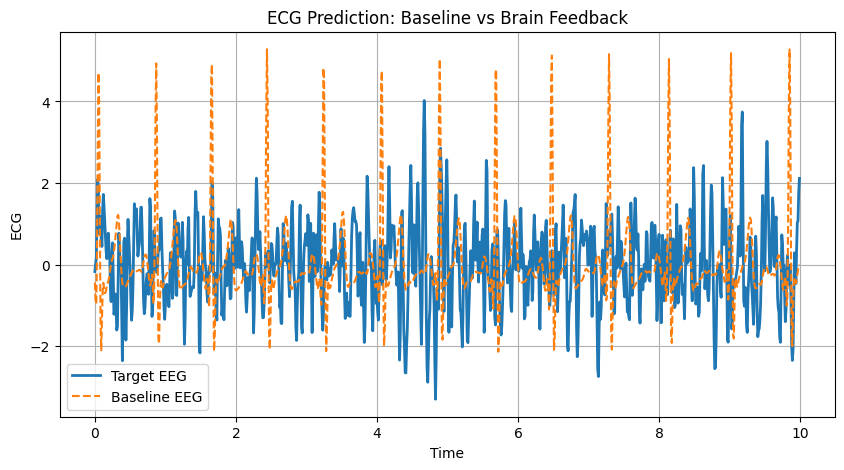

In [29]:
t_duration = 10
fs = 100
t = np.arange(0, t_duration, 1/fs)
plt.figure(figsize=(10,5))
target_signal_eeg = eeg_processed[0, ::10]
target_signal_ecg = ecg_processed[::10]



plt.plot(t, target_signal_eeg , label='Target EEG', linewidth=2)
plt.plot(t, target_signal_ecg, label='Baseline EEG', linestyle='--')

plt.title('ECG Prediction: Baseline vs Brain Feedback')
plt.xlabel('Time')
plt.ylabel('ECG')
plt.legend()
plt.grid(True)
#        plt.savefig(f"{region_dir}/training_DATA.png")
plt.show()

In [ ]:
sed= np.corrcoef(target_signal_eeg, target_signal_ecg)[0,1]
print(sed)

0.058737290242684245


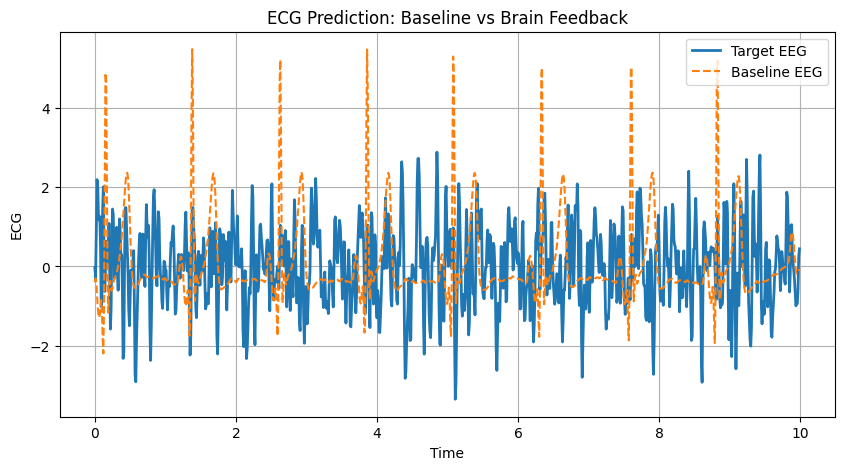

In [ ]:
t_duration = 10
fs = 100
t = np.arange(0, t_duration, 1/fs)
plt.figure(figsize=(10,5))
target_signal_eeg = eeg_processed[1, ::10]
target_signal_ecg = ecg_processed[::10]



plt.plot(t, target_signal_eeg , label='Target EEG', linewidth=2)
plt.plot(t, target_signal_ecg, label='Baseline EEG', linestyle='--')

plt.title('ECG Prediction: Baseline vs Brain Feedback')
plt.xlabel('Time')
plt.ylabel('ECG')
plt.legend()
plt.grid(True)
#        plt.savefig(f"{region_dir}/training_DATA.png")
plt.show()

In [30]:
# ── EEG regions ranked by Pearson correlation with ECG ───────────────────────

# Use alter preprocessing results (min-max normalized)
ranked = sorted(all_results_processed_alter, 
                key=lambda x: x['correlation'], 
                reverse=True)

print("\n===== EEG Regions Ranked by |Correlation| with ECG (Alter Preprocessing) =====\n")
print(f"{'Rank':<6} {'Channel':>8} {'Region':<35} {'Pearson Corr':>14}")
print("-" * 68)
for rank, res in enumerate(ranked):
    idx = res['channel_idx']
    name = region_names[idx] if idx < len(region_names) else f"Region_{idx}"
    print(f"{rank+1:<6} {idx:>8} {name:<35} {res['correlation']:>14.4f}")

# Also print just the indices in order for quick reference
ranked_indices = [r['channel_idx'] for r in ranked]
print(f"\nRanked indices (0-indexed, decreasing correlation):")
print(ranked_indices)


===== EEG Regions Ranked by |Correlation| with ECG (Alter Preprocessing) =====

Rank    Channel Region                                Pearson Corr
--------------------------------------------------------------------
1            12 fusiform L                                  0.1256
2            34 parahippocampal L                           0.1093
3            44 postcentral L                               0.0892
4            36 parsopercularis L                           0.0688
5            37 parsopercularis R                           0.0660
6            11 frontalpole R                               0.0634
7            51 precuneus R                                 0.0617
8             7 cuneus R                                    0.0607
9            16 inferiortemporal L                          0.0573
10           40 parstriangularis L                          0.0557
11           29 medialorbitofrontal R                       0.0533
12           24 lateralorbitofrontal L        